## Support Vector Classifier

This notebook examines the SupportVectorClassifier (SVC) to predict customer satisfaction.

In [1]:
%%capture
%pip install hpsklearn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, GridSearchCV
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve
import utils
from utils import *
warnings.filterwarnings(action='ignore')

In [ ]:
df = pd.read_parquet('../../data/ACME-HappinessSurvey2020_shrunk.parquet')

df.head()

,customer satisfaction,my order was delivered on time,contents of my order was as I expected,I ordered everything I wanted to order,I paid good price for my order,I am satisfied with my courier,the app makes ordering easy
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [4]:
y = df['customer satisfaction'].values
X = df.drop('customer satisfaction', axis=1)

In [5]:
seed = 5249

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=seed, shuffle=True
)

In [6]:
svc = SVC(random_state=seed, kernel='linear')

svc.fit(X_train, y_train)

return_scores(svc, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.690000,0.709091,0.722222
Test,0.461538,0.428571,0.500000


In [7]:
params = {
    'C': 10**np.linspace(-3,4,25)
}

kfold = KFold(n_splits=10, shuffle=True, random_state=seed)

grid = GridSearchCV(estimator=svc,
                    param_grid=params,
                    scoring=['accuracy', 'recall'],
                    n_jobs=-1,
                    cv=kfold,
                    return_train_score=True,
                    refit=False)

grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=5249, shuffle=True),
             estimator=SVC(kernel='linear', random_state=5249), n_jobs=-1,
             param_grid={'C': array([1.00000000e-03, 1.95734178e-03, 3.83118685e-03, 7.49894209e-03,
       1.46779927e-02, 2.87298483e-02, 5.62341325e-02, 1.10069417e-01,
       2.15443469e-01, 4.21696503e-01, 8.25404185e-01, 1.61559810e+00,
       3.16227766e+00, 6.18965819e+00, 1.21152766e+01, 2.37137371e+01,
       4.64158883e+01, 9.08517576e+01, 1.77827941e+02, 3.48070059e+02,
       6.81292069e+02, 1.33352143e+03, 2.61015722e+03, 5.10896977e+03,
       1.00000000e+04])},
             refit=False, return_train_score=True,
             scoring=['accuracy', 'recall'])

In [8]:
grid_df = pd.DataFrame(grid.cv_results_)
grid_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,split2_train_recall,split3_train_recall,split4_train_recall,split5_train_recall,split6_train_recall,split7_train_recall,split8_train_recall,split9_train_recall,mean_train_recall,std_train_recall
0,0.029401,0.011445,0.013310,0.003418,0.001000,{'C': 0.001},0.6,0.7,0.9,0.2,...,1.000000,1.0,1.00,1.00,1.00,1.000000,1.000000,1.000000,1.000000,0.000000
1,0.004957,0.002824,0.005530,0.001923,0.001957,{'C': 0.0019573417814876598},0.6,0.7,0.9,0.2,...,1.000000,1.0,1.00,1.00,1.00,1.000000,1.000000,1.000000,1.000000,0.000000
2,0.003538,0.001924,0.003830,0.000849,0.003831,{'C': 0.003831186849557289},0.6,0.7,0.9,0.2,...,1.000000,1.0,1.00,1.00,1.00,1.000000,1.000000,1.000000,1.000000,0.000000
3,0.002904,0.000869,0.004478,0.000650,0.007499,{'C': 0.007498942093324558},0.6,0.7,0.7,0.2,...,0.847826,1.0,1.00,1.00,1.00,1.000000,1.000000,1.000000,0.980616,0.045973
4,0.006691,0.003923,0.009769,0.003782,0.014678,{'C': 0.014677992676220698},0.6,0.6,0.6,0.2,...,0.782609,1.0,0.94,0.98,0.88,0.980392,0.897959,0.918367,0.906938,0.068311


In [9]:
grid_df.sort_values(by='param_C', ascending=True, inplace=True)

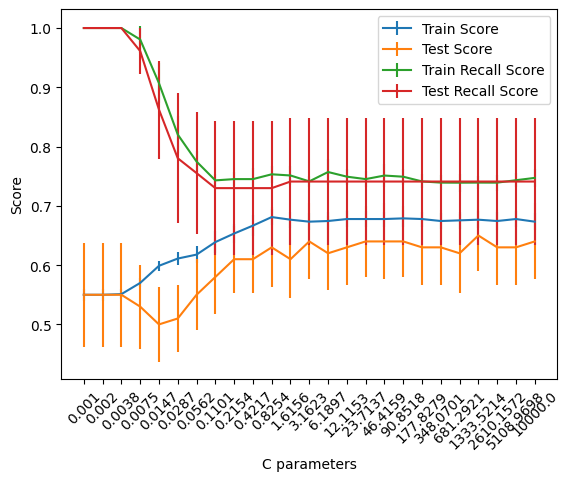

In [10]:
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_train_accuracy'],
    yerr=grid_df['std_train_accuracy']/np.sqrt(4),
    label='Train Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_test_accuracy'],
    yerr=grid_df['std_test_accuracy']/np.sqrt(4),
    label='Test Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_train_recall'],
    yerr=grid_df['std_train_recall']/np.sqrt(4),
    label='Train Recall Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_test_recall'],
    yerr=grid_df['std_test_recall']/np.sqrt(4),
    label='Test Recall Score'
    )
plt.xticks(np.arange(len(grid_df['param_C'])), round(grid_df['param_C'], 4), rotation=45)
plt.xlabel('C parameters')
plt.ylabel('Score')
plt.legend()
plt.show()

In [11]:
.0562-((.0562-.0287)/2)

0.04245

In [12]:
svc_tuned = SVC(C=.04245,
                kernel='linear',
                random_state=seed
                ).fit(X_train, y_train)

preds = svc_tuned.predict(X_test)

return_scores(svc_tuned, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.59,0.763636,0.600000
Test,0.50,0.642857,0.529412


In [13]:
coef_df = pd.DataFrame({
    'Coefficients': svc_tuned.coef_[0]
}, index=X_train.columns).sort_values(by='Coefficients', ascending=True)

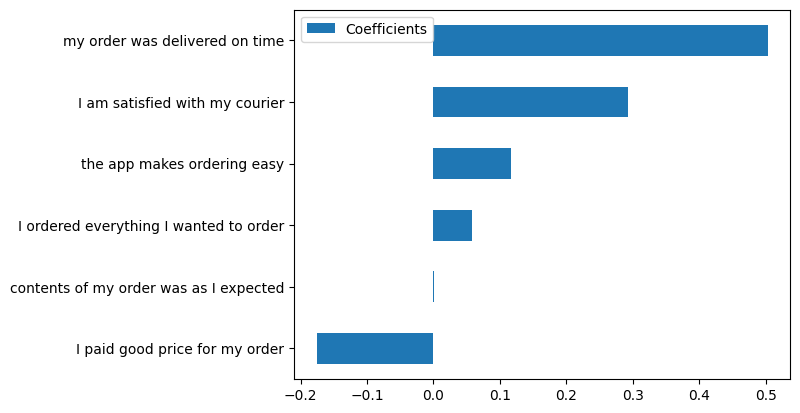

In [14]:
coef_df.plot(kind='barh')
plt.show()

In [14]:
import pathlib

path = pathlib.Path('../../feature importances/svc_coefs.csv')

if path.exists() != True:
    coef_df.to_csv(path)

### Non-Linear

In [15]:
svc_poly = SVC(random_state=seed, kernel='poly')

params = {
    'C': 10**np.linspace(-3,4,25),
}

grid = GridSearchCV(estimator=svc_poly,
                    param_grid=params,
                    scoring=['accuracy', 'recall'],
                    n_jobs=-1,
                    cv=kfold,
                    refit=False,
                    return_train_score=True)

grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=5249, shuffle=True),
             estimator=SVC(kernel='poly', random_state=5249), n_jobs=-1,
             param_grid={'C': array([1.00000000e-03, 1.95734178e-03, 3.83118685e-03, 7.49894209e-03,
       1.46779927e-02, 2.87298483e-02, 5.62341325e-02, 1.10069417e-01,
       2.15443469e-01, 4.21696503e-01, 8.25404185e-01, 1.61559810e+00,
       3.16227766e+00, 6.18965819e+00, 1.21152766e+01, 2.37137371e+01,
       4.64158883e+01, 9.08517576e+01, 1.77827941e+02, 3.48070059e+02,
       6.81292069e+02, 1.33352143e+03, 2.61015722e+03, 5.10896977e+03,
       1.00000000e+04])},
             refit=False, return_train_score=True,
             scoring=['accuracy', 'recall'])

In [16]:
grid_df = pd.DataFrame(grid.cv_results_)
grid_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,split2_train_recall,split3_train_recall,split4_train_recall,split5_train_recall,split6_train_recall,split7_train_recall,split8_train_recall,split9_train_recall,mean_train_recall,std_train_recall
0,0.115447,0.058995,0.022961,0.011809,0.001000,{'C': 0.001},0.8,0.4,0.4,0.6,...,0.673913,0.735849,0.68,0.68,0.7,0.686275,0.714286,0.673469,0.686394,0.025890
1,0.004574,0.001220,0.007411,0.001788,0.001957,{'C': 0.0019573417814876598},0.7,0.5,0.5,0.7,...,0.739130,0.754717,0.68,0.70,0.7,0.705882,0.734694,0.673469,0.704886,0.027365
2,0.011345,0.014428,0.008950,0.004718,0.003831,{'C': 0.003831186849557289},0.8,0.6,0.5,0.8,...,0.739130,0.698113,0.68,0.70,0.7,0.705882,0.714286,0.673469,0.697228,0.022524
3,0.009340,0.006315,0.035503,0.049485,0.007499,{'C': 0.007498942093324558},0.8,0.6,0.5,0.8,...,0.739130,0.679245,0.68,0.70,0.7,0.705882,0.734694,0.653061,0.695341,0.028034
4,0.035685,0.047323,0.011023,0.007592,0.014678,{'C': 0.014677992676220698},0.8,0.6,0.5,0.8,...,0.739130,0.716981,0.68,0.70,0.7,0.705882,0.734694,0.673469,0.701155,0.025340


In [17]:
grid_df.sort_values(by='param_C', ascending=True, inplace=True)

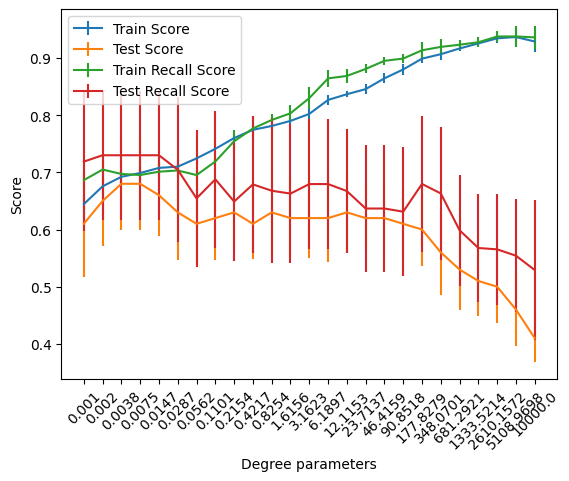

In [18]:
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_train_accuracy'],
    yerr=grid_df['std_train_accuracy']/np.sqrt(4),
    label='Train Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_test_accuracy'],
    yerr=grid_df['std_test_accuracy']/np.sqrt(4),
    label='Test Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_train_recall'],
    yerr=grid_df['std_train_recall']/np.sqrt(4),
    label='Train Recall Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_C'])),
    grid_df['mean_test_recall'],
    yerr=grid_df['std_test_recall']/np.sqrt(4),
    label='Test Recall Score'
    )
plt.xticks(np.arange(len(grid_df['param_C'])), round(grid_df['param_C'], 4), rotation=45)
plt.xlabel('Degree parameters')
plt.ylabel('Score')
plt.legend()
plt.show()

In [19]:
svc_poly.C = 12.1153
svc_poly.fit(X_train, y_train)

return_scores(svc_poly, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.840000,0.890909,0.830508
Test,0.538462,0.428571,0.600000


In [ ]:
from hpsklearn import HyperoptEstimator, any_classifier, any_preprocessing
import hyperopt
from hyperopt import hp, Trials, fmin, STATUS_OK

space = {
    'degree': hp.choice('degree', [3,4,5,6,7,8]),
    'gamma': hp.choice('gamma', 10**np.linspace(-2,4,15)),
    'C': hp.choice('C', 10**np.linspace(-3,4,25))
}

def hyperparameter_tuning(space):
    model = SVC(
        C=space['C'],
        degree=space['degree'],
        gamma=space['gamma'], 
        random_state=seed
        )
    # evaluation = [(X_train_gauss, y_train_gauss), (X_test_gauss, y_test_gauss)]

    model.fit(X_train, y_train)
    
    acc = model.score(X_test, y_test)   
    
    print()
    print(return_scores(model, X_train, X_test, y_train, y_test))
    print({'C': space['C'], 'degree': space['degree'], 'gamma': space['gamma']})

    return {'loss': -acc, 'status': STATUS_OK}

In [ ]:
trials = Trials()

best = fmin(fn=hyperparameter_tuning,
            space=space,
            algo=hyperopt.tpe.suggest,
            trials=trials,
            max_evals=50,
            verbose=0)

print(f"\nBest hyperparameter sweep: \n\t{best}")


       Accuracy  Recall  Precision
Train  0.550000     1.0   0.550000
Test   0.538462     1.0   0.538462
{'C': np.float64(0.003831186849557289), 'degree': 4, 'gamma': np.float64(0.19306977288832497)}

       Accuracy    Recall  Precision
Train  0.960000  0.981818   0.947368
Test   0.615385  0.571429   0.666667
{'C': np.float64(2610.1572156825387), 'degree': 8, 'gamma': np.float64(0.07196856730011521)}

       Accuracy    Recall  Precision
Train  0.730000  0.709091       0.78
Test   0.461538  0.285714       0.50
{'C': np.float64(12.115276586285901), 'degree': 6, 'gamma': np.float64(0.02682695795279726)}

       Accuracy  Recall  Precision
Train  0.550000     1.0   0.550000
Test   0.538462     1.0   0.538462
{'C': np.float64(0.11006941712522103), 'degree': 7, 'gamma': np.float64(10.0)}

       Accuracy  Recall  Precision
Train  0.950000     1.0   0.916667
Test   0.615385     0.5   0.700000
{'C': np.float64(681.2920690579622), 'degree': 6, 'gamma': np.float64(0.07196856730011521)}

     

In [34]:
svc_poly = SVC(
               # **best,
               C=46.41588833612782,
               degree=5,
               gamma=.517947467923121,
               kernel='poly',
               random_state=seed).fit(X_train, y_train)

return_scores(svc_poly, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.960000,0.945455,0.981132
Test,0.576923,0.571429,0.615385


In [27]:
return_scores(svc_tuned, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.59,0.763636,0.600000
Test,0.50,0.642857,0.529412


Using a non-linear kernel for the SVC model we can see an improvement in all metrics, but unfortunately the non-linear model is overfitting too much.

Let's see what different tree based models can yield and if we can bring down the overfitting.

See dt.ipynb next...